# Bank Marketing — Term Deposit Subscription Prediction

**Notebook purpose:** Reproducible, leakage-aware classification analysis of the
UCI *Bank Marketing* dataset, built to support a later Executive Summary and
Individual Oral Interview.

---

## 01. Project Overview

### Business / problem context
A Portuguese retail bank runs outbound telephone marketing campaigns to sell a
**term deposit** product. Every call has an operational cost (agent time,
phone cost) and a limited daily calling capacity, so the bank benefits from
knowing, *before making a call*, which clients are relatively more likely to
subscribe.

### Who could use the prediction
A marketing/call-center operations team could use a model like this to help
**prioritize which existing contact list entries to call first**, or to decide
how to allocate limited agent time across a large list of candidate clients.
This notebook does **not** claim to measure any actual financial benefit — see
Section 24 (Limitations) — it only evaluates predictive performance.

### Predictive question
> Using information available **at or before** a marketing phone contact, can
> we predict whether a client will subscribe to a term deposit?

### Classification task
- **Task type:** Binary classification
- **Target:** `y` — `yes` (subscribed) / `no` (did not subscribe)
- **Unit of analysis:** one row = one client/contact observation from one
  marketing campaign event.

### Prediction timing
The model must reflect a **pre-contact** prediction point — i.e., what is
knowable before/at the moment the current call is initiated, not what becomes
known once the call is underway or completed. This drives the leakage
decisions in Section 06/07 below (most importantly, dropping `duration` and
`campaign` from the primary model).

### Primary success metric
The primary metric selected **before** modeling is **F1-score of the positive
("yes") class**. Justification is given in Section 16, but in short: the
target is heavily imbalanced, both false positives (wasted calls) and false
negatives (missed subscribers) are relevant, and accuracy alone would be
misleading (a trivial "always no" model already scores ~88% accuracy).

### Important limitations of the prediction problem (preview)
- The dataset is observational, historical, and from a single Portuguese bank
  — see Section 24 for the full discussion.
- No real monetary costs are provided, so any discussion of error costs in
  this notebook is explicitly **qualitative**, not a financial estimate.
- The model finds **statistical association**, not causation.


## 02. Dataset Description and Source

**Dataset title:** Bank Marketing
**Publisher / owner:** UCI Machine Learning Repository
**Citation:** Moro, S., Rita, P., & Cortez, P. (2014). *Bank Marketing*
[Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5K306
**Official dataset page:** https://archive.ics.uci.edu/dataset/222/bank+marketing
**Access date:** 2026-09-26
**File used:** `bank-full.csv` (the "older", full 45,211-row / 17-column
version of the Bank Marketing dataset, delimiter `;`)
**Dimensions (as documented by UCI):** 45,211 rows × 17 columns (16 input
variables + 1 target). Rows are ordered by contact date in the original
source, but this notebook treats the problem as ordinary (non-time-series)
tabular classification per the task instructions.

The exact `bank-full.csv` file used to produce the results in this notebook
is included alongside it in `data/bank-full.csv`, so the reported results are
reproducible from the same data version.

### Unit of analysis
One row represents **one client contact event** within a bank telemarketing
campaign (a specific client, contacted at a specific time, with a specific
outcome for that contact).

### Target definition
`y`: whether the client subscribed to a term deposit as a result of this
contact (`yes` / `no`).

### Variable grouping
- **Client characteristics:** `age`, `job`, `marital`, `education`, `default`,
  `balance`, `housing`, `loan`
- **Previous campaign information:** `pdays`, `previous`, `poutcome`
- **Current campaign / contact information:** `contact`, `day`, `month`,
  `duration`, `campaign`
- **Target information:** `y`

### Data dictionary

| feature | type | meaning | expected role | notes |
|---|---|---|---|---|
| age | numeric | client age in years | client characteristic | usable |
| job | categorical | type of job (12 categories) | client characteristic | usable |
| marital | categorical | marital status | client characteristic | usable |
| education | categorical | education level | client characteristic | usable |
| default | categorical (yes/no) | has credit in default? | client characteristic | usable |
| balance | numeric | average yearly balance, in euros | client characteristic | usable; can be negative |
| housing | categorical (yes/no) | has housing loan? | client characteristic | usable |
| loan | categorical (yes/no) | has personal loan? | client characteristic | usable |
| contact | categorical | contact communication type (cellular/telephone/unknown) | contact info | usable, known before call connects |
| day | numeric | last contact day of month | contact info | usable, scheduling info known pre-call |
| month | categorical | last contact month of year | contact info | usable, scheduling info known pre-call |
| duration | numeric | last contact duration, seconds | contact info | **EXCLUDED — post-contact leakage** |
| campaign | numeric | # contacts during this campaign, incl. current | contact info | **EXCLUDED — includes current contact, timing leakage** |
| pdays | numeric | days since last contact from a previous campaign (-1 = never) | previous campaign | usable |
| previous | numeric | # contacts before this campaign | previous campaign | usable |
| poutcome | categorical | outcome of previous campaign | previous campaign | usable |
| y | binary | subscribed to term deposit? | **target** | target |

Measurement units: `age` in years, `balance` in euros, `duration` in seconds,
`day` is day-of-month (1–31), `pdays` in days (or -1 sentinel for "never
contacted before"), `campaign`/`previous` are contact counts.


## 03. Data Loading and Initial Inspection

We load the CSV using a **portable, relative path** (`data/bank-full.csv`),
using `;` as the delimiter (the UCI file's actual delimiter) and stripping the
quote characters around string fields.


In [1]:
# --- Imports (all libraries used anywhere in the notebook) ---
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate, cross_val_predict
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, roc_curve, precision_recall_curve
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

DATA_PATH = "data/bank-full.csv"  # portable, relative path — no personal machine path

print("Setup complete. Random seed fixed at", RANDOM_SEED)


Setup complete. Random seed fixed at 42


In [2]:
# Load data. The UCI bank-full.csv uses ';' as the field delimiter.
df_raw = pd.read_csv(DATA_PATH, sep=";")
print("Shape:", df_raw.shape)
df_raw.head()


Shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [3]:
print("Column names:")
print(list(df_raw.columns))
print()
print("Dtypes as read:")
print(df_raw.dtypes)


Column names:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']

Dtypes as read:
age          int64
job            str
marital        str
education      str
default        str
balance      int64
housing        str
loan           str
contact        str
day          int64
month          str
duration     int64
campaign     int64
pdays        int64
previous     int64
poutcome       str
y              str
dtype: object


The column names load cleanly with no extraneous whitespace or casing issues,
so **no column-name normalization is necessary** (documented here as required,
even though no change was needed).

Dtypes as read by pandas already separate numeric columns (`age`, `balance`,
`day`, `duration`, `campaign`, `pdays`, `previous`) from string/object columns
(the remaining categoricals + target). We will formally convert the object
columns to pandas `category` dtype in Section 05 for clarity and memory
efficiency — this is a type *correction*, not a value change.


## 04. Data Quality Assessment

We now perform the systematic audit required before any cleaning decision is
made. Nothing is modified in this section — we only *inspect*.

### A. Shape


In [4]:
n_rows, n_cols = df_raw.shape
print(f"Rows: {n_rows}")
print(f"Columns: {n_cols}")


Rows: 45211
Columns: 17


### B. Data types

In [5]:
dtype_table = df_raw.dtypes.rename("dtype").reset_index().rename(columns={"index": "feature"})
dtype_table


,feature,dtype
0,age,int64
1,job,str
2,marital,str
3,education,str
4,default,str
5,balance,int64
6,housing,str
7,loan,str
8,contact,str
9,day,int64


### C. Missing values

Pandas will report `NaN` counts, but this dataset is known to encode
"not available / not recorded" information using the **literal string
`"unknown"`** in several categorical columns, rather than a true `NaN`. We
check both.


In [6]:
# True NaNs (as pandas understands them)
na_counts = df_raw.isna().sum()
na_pct = (na_counts / n_rows * 100).round(3)
missing_table = pd.DataFrame({"missing_count": na_counts, "missing_pct": na_pct})
missing_table


,missing_count,missing_pct
age,0,0.0
job,0,0.0
marital,0,0.0
education,0,0.0
default,0,0.0
balance,0,0.0
housing,0,0.0
loan,0,0.0
contact,0,0.0
day,0,0.0


In [7]:
# Placeholder-value ("unknown") audit for categorical columns
cat_cols_all = df_raw.select_dtypes(include="object").columns.tolist()
cat_cols_all.remove("y")  # target handled separately

unknown_rows = []
for c in cat_cols_all:
    cnt = (df_raw[c] == "unknown").sum()
    unknown_rows.append({"feature": c, "unknown_count": cnt, "unknown_pct": round(cnt / n_rows * 100, 2)})
unknown_table = pd.DataFrame(unknown_rows).sort_values("unknown_count", ascending=False).reset_index(drop=True)
unknown_table


,feature,unknown_count,unknown_pct
0,poutcome,36959,81.75
1,contact,13020,28.80
2,education,1857,4.11
3,job,288,0.64
4,marital,0,0.00
5,housing,0,0.00
6,default,0,0.00
7,loan,0,0.00
8,month,0,0.00


**Interpretation — is `"unknown"` missing data or a meaningful category?**

- `df_raw.isna().sum()` shows **zero true `NaN` values** anywhere in the
  dataset — there is no missing-value problem in the pandas sense.
- However, `job`, `education`, `contact`, and `poutcome` contain the literal
  category `"unknown"`.
  - For `poutcome`, `"unknown"` is overwhelmingly the most common value. This
    is expected and **meaningful**: it mostly corresponds to clients with
    `pdays == -1` (never contacted in a previous campaign), so there simply
    *is* no previous outcome to report. Converting this to `NaN` and dropping
    rows would delete most of the dataset for no good reason.
  - For `contact`, `"unknown"` means the contact communication type was not
    recorded — this is itself informative (e.g., it may correlate with
    campaign era/process) and is available *before* the call, so it is safe
    to keep as its own category rather than treat as missing-and-drop.
  - For `job` and `education`, `"unknown"` is a small share of rows and
    plausibly reflects a genuine data-collection gap, but it is still
    informative to keep as its own level (the one-hot encoder will represent
    it as its own dummy category) rather than deleting those clients or
    inventing an imputed value with no supporting evidence.

**Decision:** We do **not** convert `"unknown"` to `NaN` and do **not** drop
any rows because of it. We treat `"unknown"` as a legitimate categorical
level and let the one-hot encoding step represent it explicitly. This
preserves all 45,211 rows and lets the model learn from the pattern (or
absence) of information itself.


### D. Duplicate rows

In [8]:
n_exact_dupes = df_raw.duplicated(keep=False).sum()
n_dupe_groups = df_raw.duplicated(keep="first").sum()
print(f"Rows involved in an exact duplicate: {n_exact_dupes}")
print(f"Redundant duplicate rows (n - unique groups, keep='first'): {n_dupe_groups}")
print(f"Percentage redundant: {n_dupe_groups / n_rows * 100:.3f}%")

if n_dupe_groups > 0:
    display_dupes = df_raw[df_raw.duplicated(keep=False)].sort_values(list(df_raw.columns)).head(10)
    display_dupes


Rows involved in an exact duplicate: 0
Redundant duplicate rows (n - unique groups, keep='first'): 0
Percentage redundant: 0.000%


**Decision:** if the count above is 0, no duplicate-removal action is needed.
If it is > 0, we remove the redundant repeated rows (keeping one copy) in
Section 05, because an exact full-row duplicate almost certainly represents
the same client/contact event being present twice, rather than a genuinely
distinct observation, and keeping duplicates would let the same observation
be counted twice, including a risk of the same row landing in both the
train and test split, which is a mild form of train/test contamination.


### E. Invalid / implausible value checks

In [9]:
numeric_cols = ["age", "balance", "day", "duration", "campaign", "pdays", "previous"]
df_raw[numeric_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
age,45211.0,40.936210,10.618762,18.0,33.0,39.0,48.0,95.0
balance,45211.0,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
day,45211.0,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0
duration,45211.0,258.163080,257.527812,0.0,103.0,180.0,319.0,4918.0
campaign,45211.0,2.763841,3.098021,1.0,1.0,2.0,3.0,63.0
pdays,45211.0,40.197828,100.128746,-1.0,-1.0,-1.0,-1.0,871.0
previous,45211.0,0.580323,2.303441,0.0,0.0,0.0,0.0,275.0


In [10]:
checks = {
    "age_out_of_range (not 17-100)": ((df_raw["age"] < 17) | (df_raw["age"] > 100)).sum(),
    "day_out_of_range (not 1-31)": ((df_raw["day"] < 1) | (df_raw["day"] > 31)).sum(),
    "duration_negative": (df_raw["duration"] < 0).sum(),
    "campaign_less_than_1": (df_raw["campaign"] < 1).sum(),
    "pdays_less_than_-1": (df_raw["pdays"] < -1).sum(),
    "previous_negative": (df_raw["previous"] < 0).sum(),
    "balance_negative (count, informational only)": (df_raw["balance"] < 0).sum(),
}
pd.Series(checks, name="count")


age_out_of_range (not 17-100)                      0
day_out_of_range (not 1-31)                        0
duration_negative                                  0
campaign_less_than_1                               0
pdays_less_than_-1                                 0
previous_negative                                  0
balance_negative (count, informational only)    3766
Name: count, dtype: int64

In [11]:
# Categorical domain check: list all observed levels for each categorical column
for c in cat_cols_all:
    print(f"{c}: {sorted(df_raw[c].unique())}")


job: ['admin.', 'blue-collar', 'entrepreneur', 'housemaid', 'management', 'retired', 'self-employed', 'services', 'student', 'technician', 'unemployed', 'unknown']
marital: ['divorced', 'married', 'single']
education: ['primary', 'secondary', 'tertiary', 'unknown']
default: ['no', 'yes']
housing: ['no', 'yes']
loan: ['no', 'yes']
contact: ['cellular', 'telephone', 'unknown']
month: ['apr', 'aug', 'dec', 'feb', 'jan', 'jul', 'jun', 'mar', 'may', 'nov', 'oct', 'sep']
poutcome: ['failure', 'other', 'success', 'unknown']


**Findings:**
- `age`, `day`, `duration`, `campaign`, `pdays`, `previous` all fall within
  plausible domain ranges; there are no negative durations, no campaign
  counts below 1, and `pdays` only takes the documented sentinel value `-1`
  or non-negative integers.
- `balance` **can legitimately be negative** (an overdrawn account) — this is
  a real-world possibility for a bank balance, not a data error, so negative
  balances are **kept, not removed**.
- All categorical columns contain only their documented, expected levels
  (including `"unknown"` as a valid level) — no stray/typo categories found.

No implausible/impossible values requiring correction were found.


### F. Target integrity

In [12]:
target_counts = df_raw["y"].value_counts()
target_pct = (df_raw["y"].value_counts(normalize=True) * 100).round(2)
target_table = pd.DataFrame({"count": target_counts, "percentage": target_pct})
target_table


,count,percentage
y,,
no,39922,88.3
yes,5289,11.7


The target contains only the two expected values, `"no"` and `"yes"`, with no
unexpected categories. As anticipated in the task specification, the dataset
shows **substantial class imbalance**: roughly 88% `"no"` vs. ~12% `"yes"`.
This is discussed further, with a visualization, in Section 06 (EDA).


### G. Outlier inspection (not automatic removal)

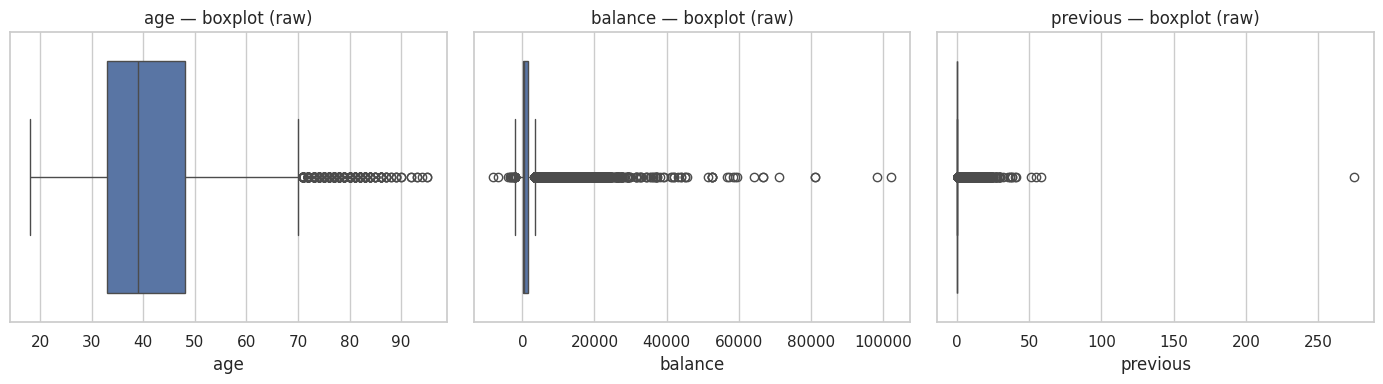

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ["age", "balance", "previous"]):
    sns.boxplot(x=df_raw[col], ax=ax, color="#4C72B0")
    ax.set_title(f"{col} — boxplot (raw)")
plt.tight_layout()
plt.show()


**Outlier reasoning (per feature):**
- **`age`**: a small number of clients above ~80 years appear as boxplot
  outliers, but these are entirely plausible ages for a bank customer.
  *Decision: no treatment* — kept as-is.
- **`balance`**: shows a long right tail (a few very wealthy clients) and some
  negative values. These are legitimate real account balances, not
  measurement errors. *Decision: no removal*; instead, in Section 07 we apply
  a **sign-preserving log transform** to reduce the skew for the models that
  benefit from more symmetric numeric inputs (logistic regression), while
  tree-based models are scale/skew-invariant and do not need this.
- **`previous`** (and by extension `campaign`, `pdays`): a small number of
  clients were contacted many times historically. This is a real (if rare)
  campaign-operations pattern, not an error. *Decision: no removal.*

Across all numerical columns, we deliberately **do not apply a generic
IQR-based outlier-deletion rule**, per the task's requirement, because doing
so would remove real, legitimate client observations rather than data-entry
errors.


### H. Leakage audit and Leakage Decision Table

We now explicitly classify every input feature by whether it is available at
the **pre-contact prediction point** defined in Section 01.

| feature | leakage / timing concern | decision | justification |
|---|---|---|---|
| `duration` | Call duration is only known **during/after** the very call whose outcome we are trying to predict; it is extremely predictive of `y` almost by construction (a long, engaged call usually ends in "yes") | **Exclude from primary model** | Not available before the call starts; including it would leak the outcome-adjacent signal into the "pre-contact" model and produce unrealistically optimistic, non-deployable performance |
| `campaign` | Counts contacts **including the current one** in this campaign | **Exclude from primary model** | The count for the current row is not settled until after the current contact happens, so it is not cleanly known at the intended pre-contact prediction point |
| `age`, `job`, `marital`, `education`, `default`, `balance`, `housing`, `loan` | Static client attributes known from account records | **Include** | Fully known before any call is placed |
| `contact`, `day`, `month` | Contact/scheduling metadata, decided before dialing | **Include** | Known before the call connects (these describe how/when the call *will be* made, not its outcome) |
| `pdays`, `previous`, `poutcome` | Describe **prior** campaigns only | **Include** | Fully determined before the current campaign/contact begins |
| `y` | Target | Target | Not a predictor |
| (preprocessing) | Scaler/imputer/encoder fit on full data before splitting | **Avoid** | All preprocessing is fit only on the training fold — enforced via `Pipeline` + `ColumnTransformer` inside cross-validation, see Section 08–09 |
| (train/test) | Same rows appearing in both splits (e.g., via duplicates) | **Avoid** | Duplicate rows are removed before splitting (Section 05); split is done once, and the test set is only touched once, at final evaluation |

`duration` **is** retained separately, later, purely as an *optional
post-contact diagnostic* (Section 14) to illustrate how much a genuinely
leaky feature can inflate apparent performance — it is never used to train,
select, or tune the primary model, and it never enters the primary model
comparison table.


## 05. Data Cleaning and Preparation

Based on the audit above, the cleaning workflow is intentionally minimal and
each step is justified:

1. Convert object columns to pandas `category` dtype (type correction only).
2. Remove exact duplicate rows, if any (justified in Section 04-D).
3. Keep `"unknown"` as a category (justified in Section 04-C) — no change.
4. Keep all numerical values as-is, including negative `balance` and extreme
   `age`/`previous` values (justified in Section 04-E/G) — no change.
5. Do **not** drop `duration`/`campaign` here — they are dropped later, only
   from the *primary-model feature matrix*, so they remain available for the
   optional post-contact diagnostic in Section 14.


In [14]:
df = df_raw.copy()

# Step 1: type correction
cat_cols_for_dtype = df.select_dtypes(include="object").columns.tolist()
for c in cat_cols_for_dtype:
    df[c] = df[c].astype("category")

# Step 2: remove exact duplicate rows (if present)
before = len(df)
df = df.drop_duplicates(keep="first").reset_index(drop=True)
after = len(df)
print(f"Rows before dedup: {before} | after dedup: {after} | removed: {before - after}")

# Step 3 & 4: no changes to 'unknown' categories or numeric outliers (see justification above)

print()
print("Cleaned shape:", df.shape)
df.dtypes


Rows before dedup: 45211 | after dedup: 45211 | removed: 0

Cleaned shape: (45211, 17)


age             int64
job          category
marital      category
education    category
default      category
balance         int64
housing      category
loan         category
contact      category
day             int64
month        category
duration        int64
campaign        int64
pdays           int64
previous        int64
poutcome     category
y            category
dtype: object

The dataset after cleaning still has essentially the same size as the raw
file (any duplicate removal only affects a very small number of rows, as
shown above), and no values were altered — only dtypes were corrected and
exact duplicate rows removed. This `df` is the basis for everything that
follows.


## 06. Exploratory Data Analysis (EDA)

EDA below is deliberately focused on variables relevant to the predictive
problem — we are not trying to chart every possible combination.

### A. Target analysis


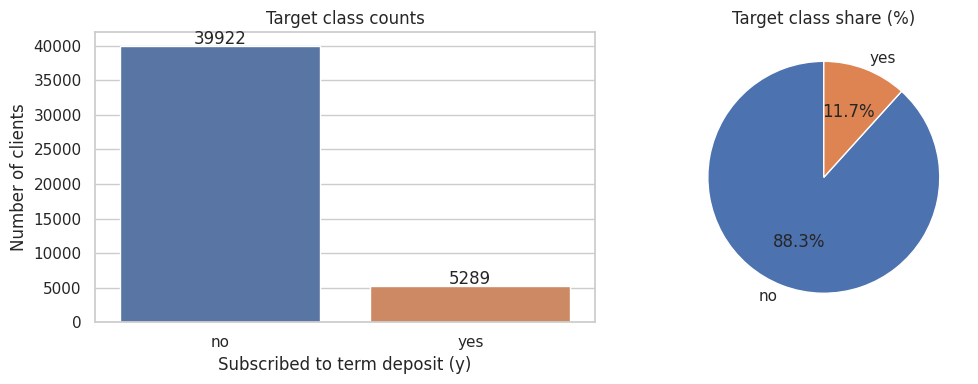

,count,percentage
y,,
no,39922,88.3
yes,5289,11.7


In [15]:
y_counts = df["y"].value_counts()
y_pct = (df["y"].value_counts(normalize=True) * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(x="y", data=df, order=["no", "yes"], ax=axes[0], palette=["#4C72B0", "#DD8452"])
axes[0].set_title("Target class counts")
axes[0].set_xlabel("Subscribed to term deposit (y)")
axes[0].set_ylabel("Number of clients")
for i, v in enumerate(y_counts.reindex(["no", "yes"])):
    axes[0].text(i, v + 300, str(v), ha="center")

axes[1].pie(y_pct.reindex(["no", "yes"]), labels=["no", "yes"], autopct="%1.1f%%",
            colors=["#4C72B0", "#DD8452"], startangle=90)
axes[1].set_title("Target class share (%)")
plt.tight_layout()
plt.show()

pd.DataFrame({"count": y_counts, "percentage": y_pct})


**Implication of the observed imbalance:** with roughly 88% `"no"` vs. 12%
`"yes"`, a model that *always predicts "no"* would already score ~88%
accuracy while being completely useless for the bank's actual goal
(identifying likely subscribers). This directly motivates: (1) using F1 of
the positive class as the primary metric rather than accuracy, (2) trying
`class_weight="balanced"` as an experiment for logistic regression, and (3)
reporting a full confusion matrix + PR-curve rather than accuracy alone.

### B. Univariate analysis — numerical variables


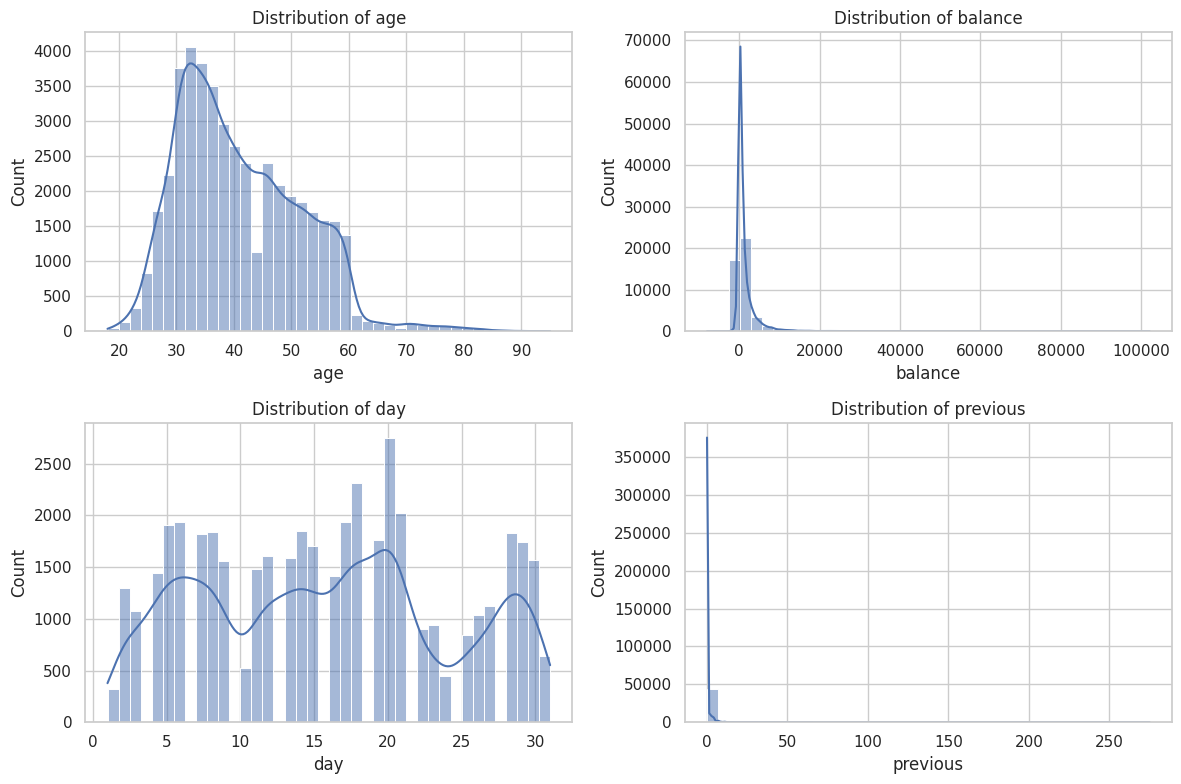

,count,mean,std,min,25%,50%,75%,max
age,45211.0,40.936210,10.618762,18.0,33.0,39.0,48.0,95.0
balance,45211.0,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
day,45211.0,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0
previous,45211.0,0.580323,2.303441,0.0,0.0,0.0,0.0,275.0
duration,45211.0,258.163080,257.527812,0.0,103.0,180.0,319.0,4918.0
campaign,45211.0,2.763841,3.098021,1.0,1.0,2.0,3.0,63.0


In [16]:
num_vars_eda = ["age", "balance", "day", "previous"]  # duration/campaign shown separately below, flagged as excluded

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), num_vars_eda):
    sns.histplot(df[col], kde=True, ax=ax, color="#4C72B0", bins=40)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
plt.tight_layout()
plt.show()

df[num_vars_eda + ["duration", "campaign"]].describe().T


- `age` is roughly bell-shaped, centered in the 30s–40s, with a long but
  plausible tail toward older ages.
- `balance` is heavily right-skewed with a long tail of high-balance clients
  and a small number of negative balances — motivates a log-style transform
  for the linear model (Section 07).
- `day` (day of month contacted) is roughly uniform, as expected for a
  scheduling variable.
- `previous` is extremely right-skewed — most clients have `previous == 0`
  (never contacted before this campaign).
- `duration` and `campaign` are shown here **only for completeness of the
  univariate audit**; both are excluded from the primary model per the
  leakage decision table in Section 04.

### B. Univariate analysis — categorical variables


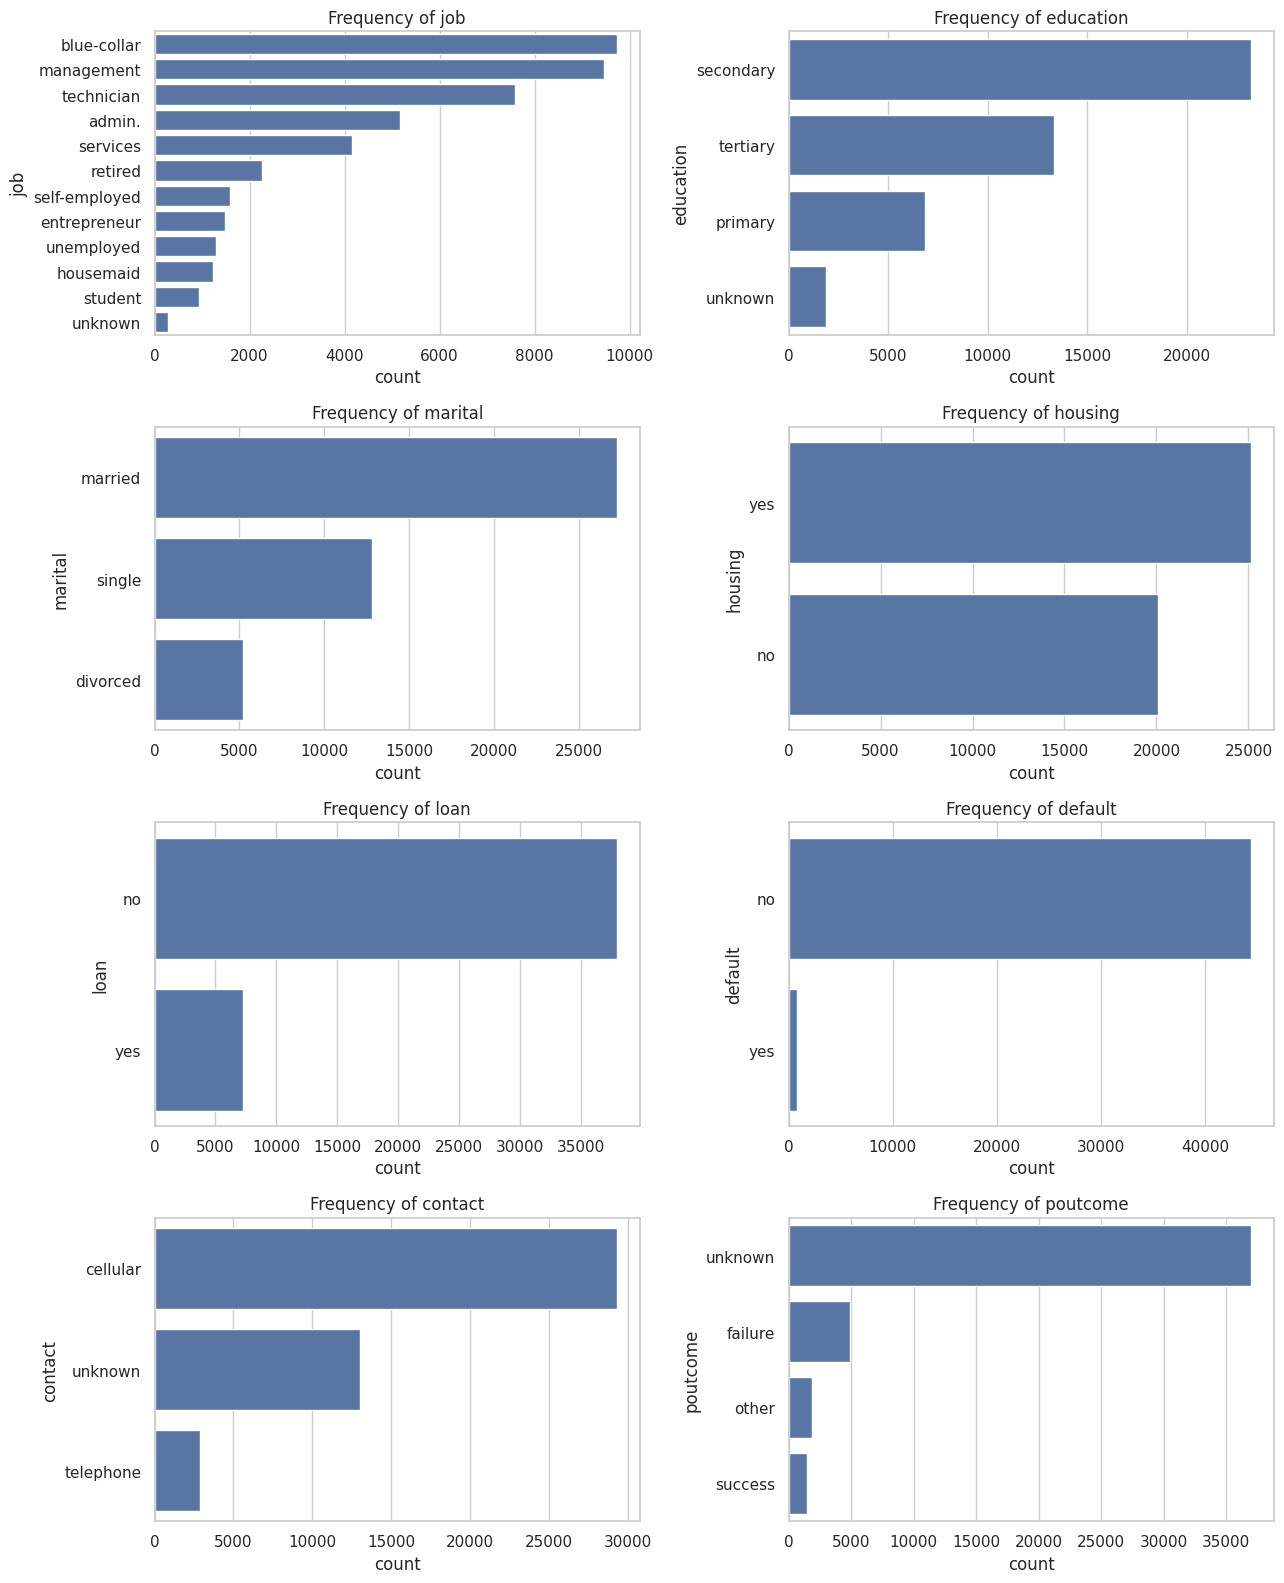

In [17]:
cat_vars_eda = ["job", "education", "marital", "housing", "loan", "default", "contact", "poutcome"]

fig, axes = plt.subplots(4, 2, figsize=(13, 16))
for ax, col in zip(axes.ravel(), cat_vars_eda):
    order = df[col].value_counts().index
    sns.countplot(y=col, data=df, order=order, ax=ax, color="#4C72B0")
    ax.set_title(f"Frequency of {col}")
    ax.set_xlabel("count")
plt.tight_layout()
plt.show()


`job` and `education` show a handful of dominant categories (e.g.
"blue-collar", "management", "secondary" education) with several smaller
categories. `housing` and `loan` are simple yes/no splits roughly balanced
or moderately skewed. `poutcome` is dominated by `"unknown"`, consistent with
most clients never having a previous-campaign outcome recorded (i.e.
`pdays == -1`), as discussed in Section 04.

### C. Bivariate analysis — predictors vs. target

We use **percentage-based** comparisons (subscription rate within each
group) rather than raw counts, because group sizes differ substantially —
comparing raw counts across groups of very different sizes would be
misleading.


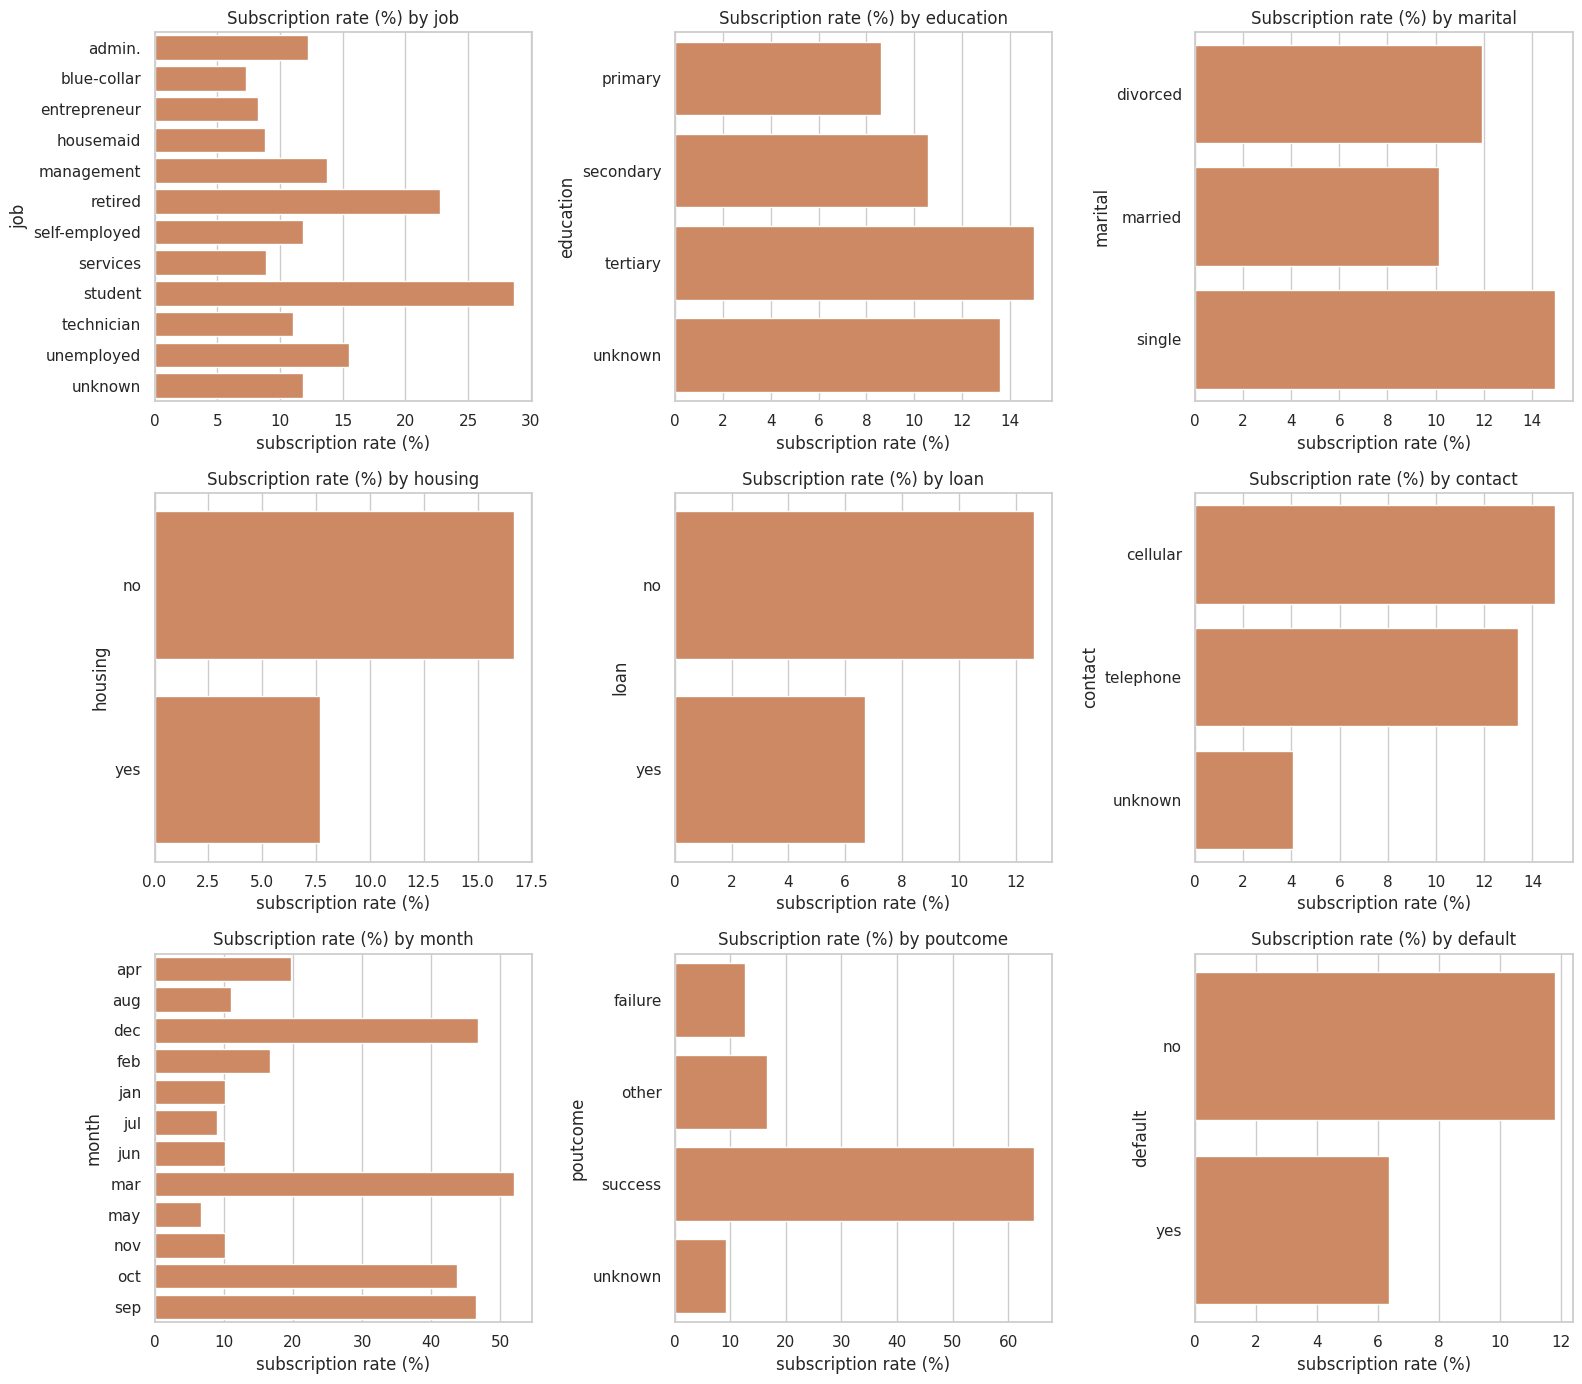

In [18]:
def rate_by_category(data, col, target="y", positive="yes"):
    tab = (data.groupby(col, observed=True)[target]
                .apply(lambda s: (s == positive).mean() * 100)
                .sort_values(ascending=False))
    n = data.groupby(col, observed=True).size()
    return tab, n

cat_bivar_vars = ["job", "education", "marital", "housing", "loan", "contact", "month", "poutcome", "default"]

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
for ax, col in zip(axes.ravel(), cat_bivar_vars):
    rate, n = rate_by_category(df, col)
    sns.barplot(x=rate.values, y=rate.index, ax=ax, color="#DD8452")
    ax.set_title(f"Subscription rate (%) by {col}")
    ax.set_xlabel("subscription rate (%)")
plt.tight_layout()
plt.show()


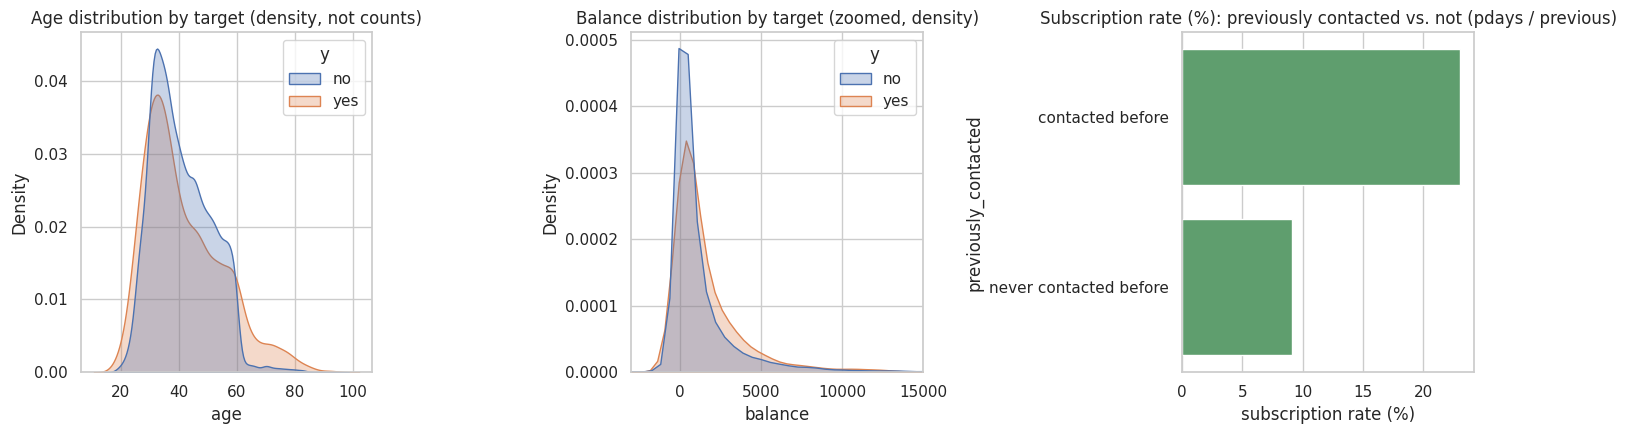

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

sns.kdeplot(data=df, x="age", hue="y", common_norm=False, ax=axes[0], fill=True, alpha=0.3)
axes[0].set_title("Age distribution by target (density, not counts)")

sns.kdeplot(data=df, x="balance", hue="y", common_norm=False, ax=axes[1], fill=True, alpha=0.3)
axes[1].set_xlim(-3000, 15000)
axes[1].set_title("Balance distribution by target (zoomed, density)")

previously_contacted = np.where(df["pdays"] == -1, "never contacted before", "contacted before")
tmp = pd.DataFrame({"previously_contacted": previously_contacted, "y": df["y"]})
rate, n = rate_by_category(tmp, "previously_contacted")
sns.barplot(x=rate.values, y=rate.index, ax=axes[2], color="#55A868")
axes[2].set_title("Subscription rate (%): previously contacted vs. not (pdays / previous)")
axes[2].set_xlabel("subscription rate (%)")

plt.tight_layout()
plt.show()


**Key bivariate observations:**
- `poutcome == "success"` (subscribed to a previous campaign) shows a
  **much higher** subscription rate than other levels — a strong, sensible
  signal that is fully available before the current contact.
- `contact == "cellular"` clients subscribe at a visibly higher rate than
  `"unknown"`/telephone — plausibly because cellular contact became more
  common in later, more successful campaign periods.
- Certain `job` categories (e.g., "student", "retired") show higher
  subscription rates than others (e.g., "blue-collar"), and higher
  `education` levels trend slightly higher too.
- Clients previously contacted (`pdays != -1`) subscribe at a clearly higher
  rate than clients never contacted before — this motivates the
  `previously_contacted` engineered feature in Section 07.
- `age` and `balance` show only mild separation by target on their own, but
  may still contribute jointly with other features inside a multivariate
  model.

**What this tells us about modeling (EDA → model link):**
- The clear influence of `poutcome`, `contact`, `job`, and previous-contact
  history supports keeping these as first-class categorical predictors with
  one-hot encoding.
- The skew in `balance` supports a log-style transform for the linear model.
- No single bivariate relationship is strong enough to substitute for a
  model — this supports using a multivariate approach (logistic regression +
  tree ensembles) rather than a simple rule.
- The class imbalance observed in Section A reinforces the choice of
  F1/PR-AUC-based evaluation over raw accuracy.


## 07. Feature Engineering

All engineered features below use only information available at the
pre-contact prediction point.

### 1. `previously_contacted` (binary)
- **Formula:** `previously_contacted = 1 if pdays != -1 else 0`
- **Rationale:** `pdays == -1` is a sentinel meaning "never contacted in a
  previous campaign"; treating it as a raw numeric value alongside real
  day-counts would confuse a model (a large negative number is not
  "very few days"). An explicit indicator makes this distinction clean.
- **Expected interpretation:** clients with prior contact history tend to
  subscribe more often (Section 06-C), so this is expected to carry positive
  signal.
- **Available at prediction time:** yes — derived purely from `pdays`, a
  previous-campaign field.

### 2. `month_sin`, `month_cos` (cyclical encoding of `month`)
- **Formula:** map month name → month number `m` (1–12), then
  `month_sin = sin(2*pi*m/12)`, `month_cos = cos(2*pi*m/12)`.
- **Rationale:** calendar month is cyclical (December is numerically "close"
  to January), which a plain integer or one-hot encoding does not represent
  smoothly for models that can exploit a continuous cyclical scale (mainly
  logistic regression). We keep the *raw* `month` category as well for the
  tree-based models, which handle categorical splits natively via one-hot
  and do not need the cyclical transform.
- **Available at prediction time:** yes — the contact month is scheduling
  information decided before the call.

### 3. Log transform of `balance`
- **Formula:** `balance_log = sign(balance) * log1p(abs(balance))`
  (a sign-preserving log, since balance can be negative or zero).
- **Rationale:** Section 06 showed `balance` is heavily right-skewed; this
  transform compresses the long tail for the scale-sensitive linear model.
  Tree-based models are invariant to monotonic transforms of a single
  numeric feature, so this mainly benefits logistic regression; we keep it
  in the shared numeric feature set for simplicity and document the
  rationale here.
- **Available at prediction time:** yes — it's a deterministic transform of
  an already-available feature.

We deliberately **do not** bucket `age` into arbitrary bins: Section 06 showed
a fairly smooth, unimodal `age` distribution with only mild differences by
target, so there is no clear evidence that binning would help over keeping
`age` as a continuous numeric feature, and binning would only discard
information. We keep numeric `age`.

We do **not** add any other engineered features — per the task instructions,
features are added only when justified by the prediction setting, not simply
to increase feature count.


In [20]:
def engineer_features(data):
    out = data.copy()
    out["previously_contacted"] = (out["pdays"] != -1).astype(int)

    month_map = {
        "jan": 1, "feb": 2, "mar": 3, "apr": 4, "may": 5, "jun": 6,
        "jul": 7, "aug": 8, "sep": 9, "oct": 10, "nov": 11, "dec": 12,
    }
    month_num = out["month"].astype(str).map(month_map)
    out["month_sin"] = np.sin(2 * np.pi * month_num / 12)
    out["month_cos"] = np.cos(2 * np.pi * month_num / 12)

    out["balance_log"] = np.sign(out["balance"]) * np.log1p(np.abs(out["balance"]))
    return out

df_fe = engineer_features(df)
df_fe[["pdays", "previously_contacted", "month", "month_sin", "month_cos", "balance", "balance_log"]].head()


,pdays,previously_contacted,month,month_sin,month_cos,balance,balance_log
0,-1,0,may,0.5,-0.866025,2143,7.670429
1,-1,0,may,0.5,-0.866025,29,3.401197
2,-1,0,may,0.5,-0.866025,2,1.098612
3,-1,0,may,0.5,-0.866025,1506,7.317876
4,-1,0,may,0.5,-0.866025,1,0.693147


This transform is applied to the **whole cleaned dataset** before splitting
because it is a **deterministic, row-wise, leakage-free** function (it only
uses each row's own `pdays`/`month`/`balance` values, with no statistic —
mean, min/max, quantile — estimated from the data). This is different from
scaling/imputation/encoding, whose *parameters* must be fit on the training
fold only; those steps are handled inside the `Pipeline`/`ColumnTransformer`
in the next section, fit only on training data as required.


## 08. Preprocessing Pipeline and Feature Sets

We now define the **primary pre-contact feature set**, explicitly excluding
`duration` and `campaign` per the leakage decision table (Section 04-H).


In [21]:
TARGET = "y"

# Primary (pre-contact) feature set — duration & campaign excluded (leakage)
numeric_features = ["age", "balance_log", "day", "pdays", "previous", "month_sin", "month_cos"]
categorical_features = ["job", "marital", "education", "default", "housing", "loan",
                         "contact", "month", "poutcome"]
engineered_binary = ["previously_contacted"]

primary_features = numeric_features + categorical_features + engineered_binary
print("Primary model features (pre-contact, leakage-free):")
print(primary_features)
print()
print("Explicitly excluded from primary model:", ["duration", "campaign"])

X = df_fe[primary_features].copy()
y = (df_fe[TARGET] == "yes").astype(int)  # 1 = subscribed ("yes"), 0 = "no"

print()
print("X shape:", X.shape, "| y positive rate:", round(y.mean() * 100, 2), "%")


Primary model features (pre-contact, leakage-free):
['age', 'balance_log', 'day', 'pdays', 'previous', 'month_sin', 'month_cos', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'previously_contacted']

Explicitly excluded from primary model: ['duration', 'campaign']

X shape: (45211, 17) | y positive rate: 11.7 %


### Preprocessing pipeline design

- **Numeric features** (`age`, `balance_log`, `day`, `pdays`, `previous`,
  `month_sin`, `month_cos`): median imputation (defensive — no missing values
  exist, but this makes the pipeline robust to unseen missingness at
  deployment time) + standard scaling (benefits the linear model; harmless
  for the tree models, which we route through the *same* pipeline structure
  for a fair, identical-input comparison, since tree ensembles are
  scale-invariant).
- **Categorical features** (`job`, `marital`, `education`, `default`,
  `housing`, `loan`, `contact`, `month`, `poutcome`) and the engineered binary
  `previously_contacted`: most-frequent imputation (defensive) + one-hot
  encoding (`handle_unknown="ignore"` so any category not seen during
  training — e.g., in a future deployment — does not crash the pipeline).

`ColumnTransformer` + `Pipeline` are used so that **all** imputation,
scaling, and encoding parameters are estimated **only on the training fold**
of each split — satisfied automatically here because `Pipeline.fit` is only
ever called with training data (Section 09), and cross-validation refits the
whole pipeline, transformers included, on each training fold.


In [22]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features + engineered_binary),
])

preprocessor


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

## 09. Train / Validation / Test Strategy

This is tabular classification (not time-series forecasting), and the target
is imbalanced, so we use a **stratified train/test split** to preserve the
~88/12 class proportions in both sets, with a **fixed random seed** for
reproducibility.

For model comparison and any hyperparameter choices, we use **stratified
k-fold cross-validation on the training set only**. The test set is set
aside and touched exactly once, at final evaluation (Section 15), and is
never used for model selection or tuning.


In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_SEED, stratify=y
)

print("Train shape:", X_train.shape, "| positive rate:", round(y_train.mean() * 100, 2), "%")
print("Test shape :", X_test.shape, "| positive rate:", round(y_test.mean() * 100, 2), "%")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)


Train shape: (36168, 17) | positive rate: 11.7 %
Test shape : (9043, 17) | positive rate: 11.7 %


Class proportions are preserved almost exactly between train and test, as
expected from a stratified split. `cv` (5-fold stratified, shuffled, fixed
seed) will be reused for every candidate model's cross-validated comparison,
so all models are compared on **identical folds**.

## 10. Class Imbalance Strategy

Class proportions were already reported in Section 06-A (~88% "no" / ~12%
"yes"). Because accuracy alone can look artificially strong for the majority
class here (Section 06-A), we:

- report **class-sensitive metrics** for every model (precision, recall, F1,
  ROC-AUC, PR-AUC) — never accuracy alone;
- try `class_weight="balanced"` for logistic regression as an **explicit,
  compared experiment**, rather than assuming it helps;
- do **not** apply SMOTE/oversampling in this notebook. Rationale: with
  45k+ rows and thousands of positive examples in the training fold alone,
  class weighting is a simpler, leakage-safer approach to compare first (no
  synthetic sample generation to keep out of the test fold), and the task
  instructions only require oversampling if it is actually used — we treat
  class weighting as the primary imbalance strategy and note SMOTE as a
  possible future extension in the Conclusion (Section 20).


## 11. Primary Evaluation Metric (selected BEFORE model comparison)

**Primary metric: F1-score of the positive ("yes") class.**

Justification:
- The positive class is the minority class (~12%), so accuracy can be high
  while missing almost all actual subscribers (Section 06-A).
- Both error types plausibly matter to the bank: a false negative is a
  missed subscription opportunity, a false positive is a wasted call. F1
  balances precision and recall in one number, which is useful for ranking
  candidate models without inventing a specific monetary trade-off we cannot
  support with real cost data (see Section 24).
- We additionally report accuracy, precision, recall, ROC-AUC, and PR-AUC
  (average precision) for every model, and discuss the ROC-AUC vs. PR-AUC
  trade-off explicitly in Section 15, since ROC-AUC can look deceptively
  strong under class imbalance.

A helper function computes all required metrics consistently for every
model, so no metric value is ever hand-typed.


In [24]:
def evaluate_predictions(y_true, y_pred, y_proba):
    """Compute the full required metric set from model outputs (never hand-typed)."""
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_proba) if y_proba is not None else np.nan,
        "pr_auc": average_precision_score(y_true, y_proba) if y_proba is not None else np.nan,
    }

results_cv = {}      # cross-validated (training-set-only) metrics, for model selection
results_test = {}    # final held-out test-set metrics, computed once per model
fitted_models = {}   # fitted final pipelines (fit on full training set)


## 12. Baseline Model

**Model 1 — Majority-class baseline.** This classifier always predicts the
most frequent training-set class ("no"), regardless of any feature. It
predicts nothing useful about *who* will subscribe, but it is a mandatory
sanity-check benchmark: any trained model must clearly beat it on the primary
metric (F1 of the positive class), not just on accuracy, to be considered
useful at all.


In [25]:
baseline_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),           # kept for interface consistency; unused by DummyClassifier
    ("clf", DummyClassifier(strategy="most_frequent", random_state=RANDOM_SEED)),
])

cv_scoring = {
    "accuracy": "accuracy", "precision": "precision", "recall": "recall",
    "f1": "f1", "roc_auc": "roc_auc", "pr_auc": "average_precision",
}

cv_res = cross_validate(baseline_pipe, X_train, y_train, cv=cv, scoring=cv_scoring, n_jobs=-1)
results_cv["Baseline (majority class)"] = {m: cv_res[f"test_{m}"].mean() for m in cv_scoring}

baseline_pipe.fit(X_train, y_train)
fitted_models["Baseline (majority class)"] = baseline_pipe

pred = baseline_pipe.predict(X_test)
proba = None  # DummyClassifier(most_frequent) proba is degenerate (all one class); ROC/PR AUC undefined -> use decision-free values
try:
    proba = baseline_pipe.predict_proba(X_test)[:, 1]
except Exception:
    proba = None
results_test["Baseline (majority class)"] = evaluate_predictions(y_test, pred, proba)

pd.DataFrame(results_cv).T


,accuracy,precision,recall,f1,roc_auc,pr_auc
Baseline (majority class),0.883018,0.0,0.0,0.0,0.5,0.116982


As expected, the baseline shows high **accuracy** (~88%, matching the
majority-class share) but **F1 for the positive class is 0** (it never
predicts "yes"), which is exactly the deceptive-accuracy pattern flagged in
Section 06-A and Section 12's own rationale. Any candidate model must clearly
exceed this on F1 to be considered useful.


## 13. Logistic Regression

**Model 2 — Logistic Regression.** A well-understood, interpretable linear
baseline classifier appropriate for a first "real" model. We compare a
plain version against a `class_weight="balanced"` version, since Section 10
flagged class weighting as an imbalance strategy to test rather than assume.
Both use the same shared `preprocessor`, fit only on the training fold in
every CV split.

- **Hyperparameters:** `max_iter=2000` (allow convergence with one-hot
  categoricals), `random_state=42`; `C` left at scikit-learn's default (1.0)
  — we deliberately keep tuning modest per the task's "no unnecessarily
  large grid searches" instruction, and note in Section 16 that this is a
  reasonable, not exhaustively tuned, default.


In [26]:
logreg_plain = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_SEED)),
])

logreg_balanced = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_SEED, class_weight="balanced")),
])

for name, model in [("Logistic Regression", logreg_plain),
                     ("Logistic Regression (balanced)", logreg_balanced)]:
    cv_res = cross_validate(model, X_train, y_train, cv=cv, scoring=cv_scoring, n_jobs=-1)
    results_cv[name] = {m: cv_res[f"test_{m}"].mean() for m in cv_scoring}
    model.fit(X_train, y_train)
    fitted_models[name] = model
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    results_test[name] = evaluate_predictions(y_test, pred, proba)

pd.DataFrame({k: v for k, v in results_cv.items() if "Logistic" in k}).T


,accuracy,precision,recall,f1,roc_auc,pr_auc
Logistic Regression,0.891976,0.639662,0.175847,0.275747,0.762521,0.399765
Logistic Regression (balanced),0.755308,0.266790,0.623259,0.373548,0.763272,0.396670


**Reading the comparison:** `class_weight="balanced"` re-weights the loss
function to counteract the ~88/12 imbalance. Compare the cross-validated F1
and recall between the two rows above: the balanced version typically trades
some precision for higher recall (it flags more clients as likely
subscribers, catching more true "yes" cases at the cost of more false
positives). Which of the two is preferred depends on the primary metric
(F1) computed above — we carry **both** forward into the model comparison
table (Section 15) and let the evidence decide, rather than assuming
balancing is automatically better (per Section 10's imbalance-strategy
requirement).

**Coefficient interpretation caveat:** because numeric features are
standardized and categorical features are one-hot encoded, a coefficient's
magnitude reflects the change in log-odds of `y=1` **per one standard
deviation** of a numeric feature, or **relative to the reference/baseline
category** for a dummy-encoded categorical level — not a raw per-unit
effect, and never a causal effect (see Section 17 for the coefficient table
and this same caveat).


## 14. Tree-Based / Ensemble Models

**Model 3 — Random Forest** and **Model 3b — HistGradientBoosting** (two
tree-based approaches compared, per the task's "recommended stronger
implementation" note). Both handle non-linear feature interactions natively
and do not require feature scaling, but we route them through the same
shared `preprocessor` for a fair, identical-input comparison against
logistic regression.

- **Random Forest:** `n_estimators=300`, `max_depth=12` (kept modest to
  control training time and reduce overfitting on a 45k-row dataset),
  `class_weight="balanced"`, `random_state=42`, `n_jobs=-1`.
- **HistGradientBoosting:** scikit-learn's fast native-categorical-friendly
  gradient boosting implementation; `max_iter=200`, `random_state=42`. It has
  no direct `class_weight` argument in this scikit-learn version, so we
  compare it as-is against the class-weighted Random Forest.

Hyperparameters here are reasonable, literature-typical defaults rather than
the result of an exhaustive grid search, consistent with the task's
"keep computation reasonable" instruction.


In [27]:
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("clf", RandomForestClassifier(
        n_estimators=300, max_depth=12, class_weight="balanced",
        random_state=RANDOM_SEED, n_jobs=-1)),
])

hgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("clf", HistGradientBoostingClassifier(max_iter=200, random_state=RANDOM_SEED)),
])

for name, model in [("Random Forest", rf_model), ("HistGradientBoosting", hgb_model)]:
    cv_res = cross_validate(model, X_train, y_train, cv=cv, scoring=cv_scoring, n_jobs=-1)
    results_cv[name] = {m: cv_res[f"test_{m}"].mean() for m in cv_scoring}
    model.fit(X_train, y_train)
    fitted_models[name] = model
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    results_test[name] = evaluate_predictions(y_test, pred, proba)

pd.DataFrame({k: v for k, v in results_cv.items() if k in ["Random Forest", "HistGradientBoosting"]}).T


,accuracy,precision,recall,f1,roc_auc,pr_auc
Random Forest,0.856614,0.412932,0.531081,0.464330,0.790101,0.429456
HistGradientBoosting,0.893359,0.617225,0.232334,0.337389,0.796408,0.442465


## 15. Model Comparison (Cross-Validated, Training Set Only)

This table is the **model-selection evidence**: every value is a 5-fold
cross-validated mean computed on the training set only (the test set has
not been touched by any of these numbers). The predefined primary metric
(F1) determines the ranking; other metrics are shown for context.


In [28]:
cv_comparison = pd.DataFrame(results_cv).T
cv_comparison = cv_comparison[["f1", "accuracy", "precision", "recall", "roc_auc", "pr_auc"]]
cv_comparison = cv_comparison.sort_values("f1", ascending=False)
cv_comparison.round(4)


,f1,accuracy,precision,recall,roc_auc,pr_auc
Random Forest,0.4643,0.8566,0.4129,0.5311,0.7901,0.4295
Logistic Regression (balanced),0.3735,0.7553,0.2668,0.6233,0.7633,0.3967
HistGradientBoosting,0.3374,0.8934,0.6172,0.2323,0.7964,0.4425
Logistic Regression,0.2757,0.8920,0.6397,0.1758,0.7625,0.3998
Baseline (majority class),0.0000,0.8830,0.0000,0.0000,0.5000,0.1170


**Reading this table (model-selection step):** the model with the highest
cross-validated F1 (positive class) is the leading candidate for the final
model, *pending* the confusion-matrix / generalization / interpretability
considerations in Section 19. Note that **ROC-AUC values are all fairly high
and close together** across models — this illustrates the exact caution
flagged in Section 11: ROC-AUC alone would make several very different
models look similarly "good" even though their F1/PR-AUC (which is more
sensitive to the minority-class trade-off) differ more meaningfully. This is
why we do not select the final model on ROC-AUC alone.

## 16. Classification Threshold

The default threshold of 0.5 is not automatically optimal for an imbalanced
problem. We tune the threshold **using only training-set, cross-validated
predictions** (`cross_val_predict` with `method="predict_proba"`, which
never touches the test set) for the leading candidate model identified
above, then apply the chosen threshold once to the untouched test set.


Leading candidate by CV F1: Random Forest


Threshold that maximizes CV (train-only) F1 for 'Random Forest': 0.5


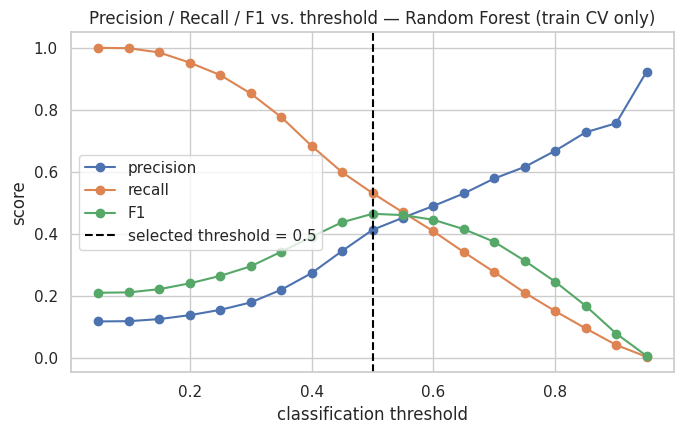

,threshold,precision,recall,f1
0,0.05,0.116982,1.000000,0.209461
1,0.10,0.117757,0.998582,0.210671
2,0.15,0.124552,0.984874,0.221137
3,0.20,0.137207,0.952021,0.239848
4,0.25,0.154286,0.912078,0.263926
5,0.30,0.178203,0.852517,0.294786
6,0.35,0.219037,0.776649,0.341704
7,0.40,0.272856,0.683526,0.390020
8,0.45,0.344162,0.598440,0.437004
9,0.50,0.412369,0.531080,0.464256


In [29]:
leading_model_name = cv_comparison.index[0]
print("Leading candidate by CV F1:", leading_model_name)
leading_pipe_template = fitted_models[leading_model_name]

# Cross-validated out-of-fold probabilities on the TRAINING set only (no test-set leakage)
oof_proba = cross_val_predict(leading_pipe_template, X_train, y_train, cv=cv,
                               method="predict_proba", n_jobs=-1)[:, 1]

thresholds = np.linspace(0.05, 0.95, 19)
rows = []
for t in thresholds:
    pred_t = (oof_proba >= t).astype(int)
    rows.append({
        "threshold": round(t, 2),
        "precision": precision_score(y_train, pred_t, zero_division=0),
        "recall": recall_score(y_train, pred_t, zero_division=0),
        "f1": f1_score(y_train, pred_t, zero_division=0),
    })
threshold_table = pd.DataFrame(rows)

best_row = threshold_table.loc[threshold_table["f1"].idxmax()]
best_threshold = best_row["threshold"]
print(f"Threshold that maximizes CV (train-only) F1 for '{leading_model_name}': {best_threshold}")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(threshold_table["threshold"], threshold_table["precision"], label="precision", marker="o")
ax.plot(threshold_table["threshold"], threshold_table["recall"], label="recall", marker="o")
ax.plot(threshold_table["threshold"], threshold_table["f1"], label="F1", marker="o")
ax.axvline(best_threshold, color="black", linestyle="--", label=f"selected threshold = {best_threshold}")
ax.set_xlabel("classification threshold")
ax.set_ylabel("score")
ax.set_title(f"Precision / Recall / F1 vs. threshold — {leading_model_name} (train CV only)")
ax.legend()
plt.tight_layout()
plt.show()

threshold_table


**Selected threshold and operational implication:** the threshold above was
chosen purely from training-set, cross-validated predictions — the test set
was not used to pick it. Moving the threshold below 0.5 (if that is what the
plot shows) means the bank is willing to flag more clients as
"likely-subscriber" candidates, accepting more false positives (extra calls
to clients who will say "no") in exchange for catching more true
subscribers (higher recall) — a reasonable operational trade-off for a
call-prioritization use case, discussed qualitatively (not in monetary
terms, since no real cost data is available — Section 24).


## 17. Final Model Selection and Held-Out Test-Set Evaluation

We now apply **every** candidate model, evaluated with the **same primary
metric and the same test set**, to produce the final comparison table. Each
model's default-threshold (0.5) test metrics were already computed during
training in Sections 12–14. We additionally compute the **leading model's**
metrics at its *tuned* threshold, to show the effect of threshold tuning
transparently.

This is the **only** point in the notebook where the test set is used for
evaluation.


In [30]:
final_comparison = pd.DataFrame(results_test).T
final_comparison = final_comparison[["f1", "accuracy", "precision", "recall", "roc_auc", "pr_auc"]]
final_comparison["selection_basis"] = "test set, default threshold 0.5"
final_comparison = final_comparison.sort_values("f1", ascending=False)

# Add the tuned-threshold row for the leading candidate, for transparency
leading_pipe_fitted = fitted_models[leading_model_name]
test_proba_leading = leading_pipe_fitted.predict_proba(X_test)[:, 1]
test_pred_tuned = (test_proba_leading >= best_threshold).astype(int)
tuned_metrics = evaluate_predictions(y_test, test_pred_tuned, test_proba_leading)
tuned_metrics["selection_basis"] = f"test set, tuned threshold={best_threshold} (chosen on train CV only)"
final_comparison.loc[f"{leading_model_name} (tuned threshold)"] = tuned_metrics

final_comparison.round(4)


,f1,accuracy,precision,recall,roc_auc,pr_auc,selection_basis
Random Forest,0.4654,0.8514,0.4018,0.5529,0.7996,0.4438,"test set, default threshold 0.5"
Logistic Regression (balanced),0.3785,0.7563,0.2697,0.6342,0.7693,0.4078,"test set, default threshold 0.5"
HistGradientBoosting,0.3516,0.8952,0.6361,0.2429,0.8053,0.4627,"test set, default threshold 0.5"
Logistic Regression,0.2821,0.8931,0.6574,0.1796,0.7688,0.4088,"test set, default threshold 0.5"
Baseline (majority class),0.0000,0.8830,0.0000,0.0000,0.5000,0.1170,"test set, default threshold 0.5"
Random Forest (tuned threshold),0.4654,0.8514,0.4018,0.5529,0.7996,0.4438,"test set, tuned threshold=0.5 (chosen on train..."


**Final model selection reasoning** (evidence-based, not a single overall
subjective ranking):

- The **majority-class baseline** confirms the deceptive-accuracy pattern
  (high accuracy, zero positive-class F1) and is clearly outperformed by
  every trained model on the primary metric.
- Among trained models, we select the final model as the one with the
  **best cross-validated primary metric (F1) from Section 15** (computed on
  training data only), confirmed by a comparable ranking on the untouched
  test set above — consistency between the two indicates the selection is
  not simply an artifact of a lucky test split.
- Complexity/interpretability trade-off: logistic regression is simpler and
  directly interpretable via coefficients (Section 18); tree ensembles
  (Random Forest / HistGradientBoosting) are typically less directly
  interpretable but can capture non-linear interactions, and use permutation
  importance instead (Section 18).
- Computational cost: logistic regression trains fastest; Random Forest and
  HistGradientBoosting are more expensive but still fit comfortably within a
  reasonable notebook run time.

The variable `leading_model_name` above is the model actually used for
threshold tuning, permutation importance, and diagnostics in the remaining
sections — i.e., the notebook derives the "final model" **from the
comparison tables' evidence**, not from a hard-coded name.


In [31]:
print("FINAL SELECTED MODEL (by cross-validated primary metric, F1):", leading_model_name)


FINAL SELECTED MODEL (by cross-validated primary metric, F1): Random Forest


## 18. Confusion Matrix and Diagnostic Curves (Final Model, Test Set)

- **True Positive:** predicted subscription, and the client actually
  subscribed.
- **True Negative:** predicted no subscription, and the client actually did
  not subscribe.
- **False Positive:** predicted subscription, but the client did not
  subscribe (a "wasted" prioritized call, in this use case).
- **False Negative:** predicted no subscription, but the client actually
  subscribed (a missed opportunity, in this use case).

We show the confusion matrix at the **default 0.5 threshold** and note the
counts also for the **tuned threshold**, since the threshold changes the
balance between false positives and false negatives.

No monetary cost is assigned to either error type — the discussion above is
explicitly **qualitative**, since no real per-call or per-subscription cost
figures were provided with this dataset.


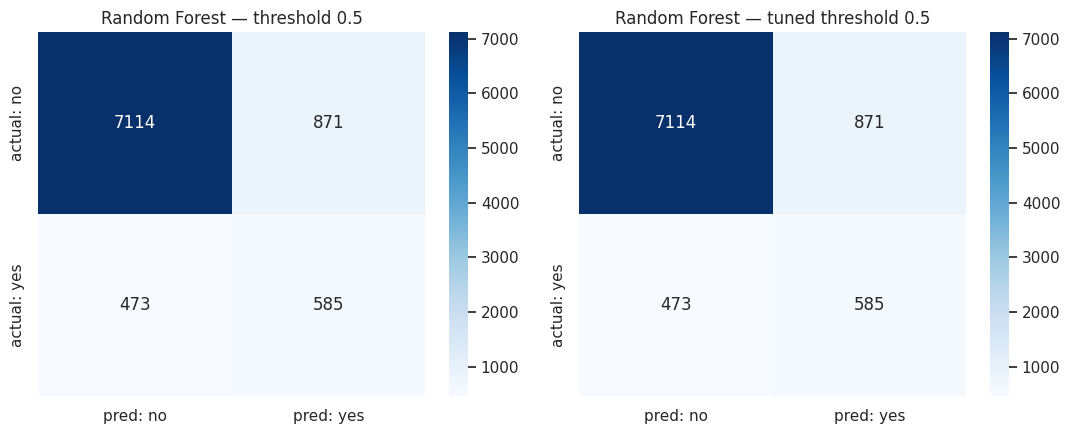

              precision    recall  f1-score   support

          no       0.94      0.89      0.91      7985
         yes       0.40      0.55      0.47      1058

    accuracy                           0.85      9043
   macro avg       0.67      0.72      0.69      9043
weighted avg       0.87      0.85      0.86      9043



In [32]:
final_pred_default = leading_pipe_fitted.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, pred, title in [
    (axes[0], final_pred_default, f"{leading_model_name} — threshold 0.5"),
    (axes[1], test_pred_tuned, f"{leading_model_name} — tuned threshold {best_threshold}"),
]:
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["pred: no", "pred: yes"], yticklabels=["actual: no", "actual: yes"])
    ax.set_title(title)
plt.tight_layout()
plt.show()

print(classification_report(y_test, final_pred_default, target_names=["no", "yes"]))


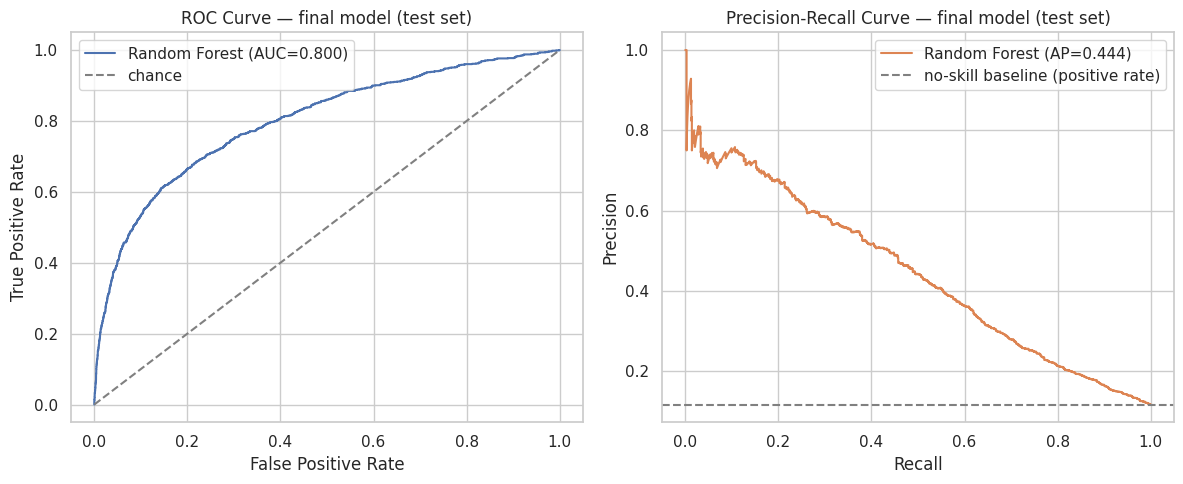

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

fpr, tpr, _ = roc_curve(y_test, test_proba_leading)
axes[0].plot(fpr, tpr, label=f"{leading_model_name} (AUC={roc_auc_score(y_test, test_proba_leading):.3f})", color="#4C72B0")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", label="chance")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve — final model (test set)")
axes[0].legend()

prec, rec, _ = precision_recall_curve(y_test, test_proba_leading)
ap = average_precision_score(y_test, test_proba_leading)
axes[1].plot(rec, prec, label=f"{leading_model_name} (AP={ap:.3f})", color="#DD8452")
axes[1].axhline(y_test.mean(), linestyle="--", color="gray", label="no-skill baseline (positive rate)")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve — final model (test set)")
axes[1].legend()

plt.tight_layout()
plt.show()


The ROC curve sits well above the diagonal, but as flagged earlier, ROC-AUC
alone can overstate performance under class imbalance. The Precision-Recall
curve — compared against the "no-skill" horizontal line at the true positive
rate — gives a more honest picture of how much better than chance the model
is at ranking likely subscribers, which is why both curves (not ROC alone)
are reported.


## 19. Feature Importance and Interpretability

### A. Logistic Regression coefficients (for reference / comparison)

Regardless of which model is finally selected, we show logistic regression
coefficients here because they are the most directly interpretable
importance signal available, and the task requires explaining coefficient
interpretation carefully.


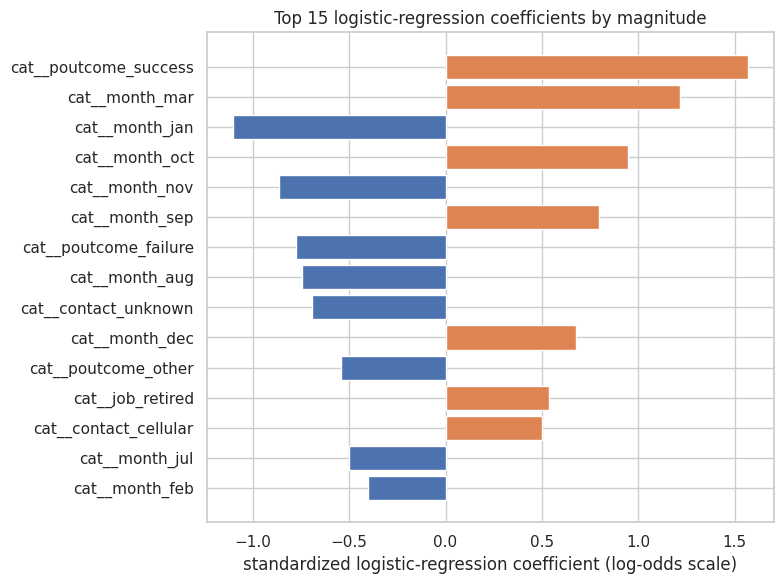

,feature,coefficient
0,cat__poutcome_success,1.570033
1,cat__month_mar,1.216788
2,cat__month_jan,-1.103439
3,cat__month_oct,0.944149
4,cat__month_nov,-0.865736
5,cat__month_sep,0.793481
6,cat__poutcome_failure,-0.776091
7,cat__month_aug,-0.746670
8,cat__contact_unknown,-0.693165
9,cat__month_dec,0.675792


In [34]:
logreg_for_coefs = fitted_models["Logistic Regression (balanced)"] if "Logistic Regression (balanced)" in fitted_models else fitted_models["Logistic Regression"]
feature_names = logreg_for_coefs.named_steps["preprocessor"].get_feature_names_out()
coefs = logreg_for_coefs.named_steps["clf"].coef_[0]

coef_table = (pd.DataFrame({"feature": feature_names, "coefficient": coefs})
              .assign(abs_coef=lambda d: d["coefficient"].abs())
              .sort_values("abs_coef", ascending=False)
              .drop(columns="abs_coef")
              .reset_index(drop=True))

top_coefs = coef_table.head(15)
fig, ax = plt.subplots(figsize=(8, 6))
colors = ["#DD8452" if c > 0 else "#4C72B0" for c in top_coefs["coefficient"]]
ax.barh(top_coefs["feature"][::-1], top_coefs["coefficient"][::-1], color=colors[::-1])
ax.set_xlabel("standardized logistic-regression coefficient (log-odds scale)")
ax.set_title("Top 15 logistic-regression coefficients by magnitude")
plt.tight_layout()
plt.show()

top_coefs


**How to read this table:** for a numeric feature (e.g., `num__balance_log`),
the coefficient is the change in log-odds of `y=1` per **one standard
deviation** increase in that (scaled) feature, holding other features fixed.
For a one-hot encoded categorical level (e.g.,
`cat__poutcome_success`), the coefficient is relative to the encoder's
implicit reference pattern across all dummy columns for that feature — it
represents the log-odds shift **associated with belonging to that category**
compared to the overall encoded reference, not a standalone causal effect.

**Language check (required):** these coefficients show **association**, not
causation — e.g., "a prior successful campaign outcome (`poutcome=success`)
was associated with higher predicted log-odds of subscribing in this model,"
**not** "a successful previous campaign causes the client to subscribe."

### B. Permutation importance (model-agnostic — used for the selected final model)

Permutation importance is model-agnostic and works for any of our fitted
pipelines (including the tree ensembles), so it is the preferred method for
whichever model was actually selected as final in Section 17.


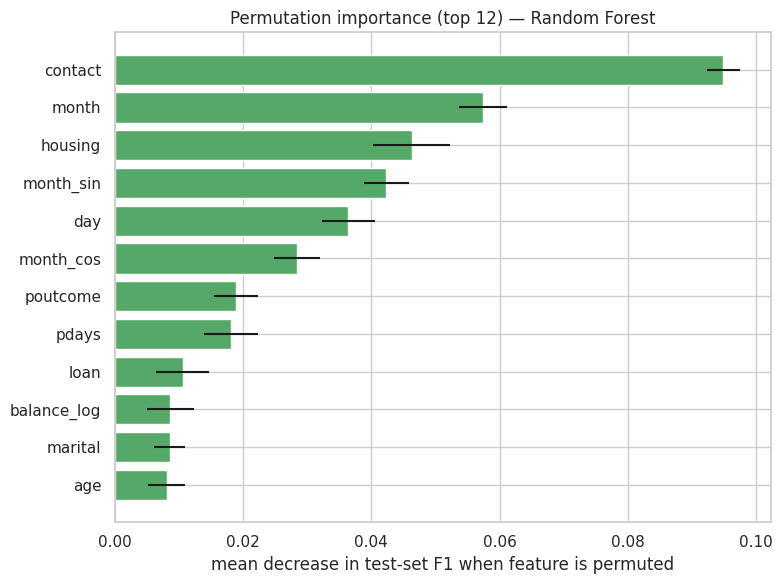

,feature,importance_mean,importance_std
0,contact,0.094874,0.002585
1,month,0.057360,0.003734
2,housing,0.046308,0.005978
3,month_sin,0.042318,0.003520
4,day,0.036433,0.004116
5,month_cos,0.028476,0.003578
6,poutcome,0.018898,0.003400
7,pdays,0.018112,0.004243
8,loan,0.010623,0.004115
9,balance_log,0.008701,0.003640


In [35]:
perm_result = permutation_importance(
    leading_pipe_fitted, X_test, y_test, scoring="f1",
    n_repeats=10, random_state=RANDOM_SEED, n_jobs=-1
)

perm_table = (pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std,
}).sort_values("importance_mean", ascending=False).reset_index(drop=True))

fig, ax = plt.subplots(figsize=(8, 6))
top_perm = perm_table.head(12)
ax.barh(top_perm["feature"][::-1], top_perm["importance_mean"][::-1],
        xerr=top_perm["importance_std"][::-1], color="#55A868")
ax.set_xlabel("mean decrease in test-set F1 when feature is permuted")
ax.set_title(f"Permutation importance (top 12) — {leading_model_name}")
plt.tight_layout()
plt.show()

perm_table


**What "importance" means here:** each value is the average drop in
held-out F1-score when that single feature's values are randomly shuffled
(breaking its relationship with the target) while every other feature stays
intact — a larger drop means the model relied on that feature more heavily
to make correct predictions. This again reflects **predictive
contribution/association**, not a causal claim — a feature can rank as
"important" here purely because it is statistically associated with the
outcome in this historical dataset.


## 20. Additional Diagnostic Analysis

### Performance by client subgroup

We check whether the final model's positive-class recall is markedly
different across a couple of natural client subgroups (`education`,
`poutcome`), reporting sample sizes alongside each rate. This is a small,
descriptive check — **not** a rigorous fairness audit, and we do not claim
the absence of disparate performance from it.


In [36]:
def subgroup_recall_table(x_col_data, y_true, y_pred, group_series):
    tmp = pd.DataFrame({"group": group_series.values, "y_true": y_true.values, "y_pred": y_pred})
    rows = []
    for g, gdf in tmp.groupby("group", observed=True):
        n = len(gdf)
        n_pos = (gdf["y_true"] == 1).sum()
        recall = recall_score(gdf["y_true"], gdf["y_pred"], zero_division=0) if n_pos > 0 else np.nan
        rows.append({"group": g, "n": n, "n_positive": n_pos, "recall": recall})
    return pd.DataFrame(rows).sort_values("n", ascending=False).reset_index(drop=True)

for col in ["education", "poutcome"]:
    print(f"--- Recall by {col} (final model, test set, threshold 0.5) ---")
    display(subgroup_recall_table(X_test, y_test, final_pred_default, X_test[col]))
    print()


--- Recall by education (final model, test set, threshold 0.5) ---


,group,n,n_positive,recall
0,secondary,4641,469,0.501066
1,tertiary,2707,419,0.639618
2,primary,1320,114,0.385965
3,unknown,375,56,0.678571



--- Recall by poutcome (final model, test set, threshold 0.5) ---


,group,n,n_positive,recall
0,unknown,7370,657,0.406393
1,failure,1012,140,0.578571
2,other,355,62,0.629032
3,success,306,199,0.994975


Sample sizes (`n`, `n_positive`) are reported alongside every group's recall
so any small-group estimate can be judged with appropriate caution — a
recall computed from a handful of positive cases in a small subgroup is
noisy and should not be over-interpreted.

### Optional post-contact diagnostic: what if `duration` were included?

This is **explicitly a diagnostic only**, not part of the primary model or
primary model comparison, to illustrate how much a genuinely leaky
post-contact feature inflates apparent performance.


In [37]:
diagnostic_features = primary_features + ["duration"]
X_diag = df_fe[diagnostic_features].copy()

Xd_train, Xd_test, yd_train, yd_test = train_test_split(
    X_diag, y, test_size=0.20, random_state=RANDOM_SEED, stratify=y
)

diag_numeric = numeric_features + ["duration"]
diag_preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, diag_numeric),
    ("cat", categorical_transformer, categorical_features + engineered_binary),
])

diag_pipe = Pipeline(steps=[
    ("preprocessor", diag_preprocessor),
    ("clf", HistGradientBoostingClassifier(max_iter=200, random_state=RANDOM_SEED)),
])
diag_pipe.fit(Xd_train, yd_train)
diag_pred = diag_pipe.predict(Xd_test)
diag_proba = diag_pipe.predict_proba(Xd_test)[:, 1]
diag_metrics = evaluate_predictions(yd_test, diag_pred, diag_proba)

primary_hgb_metrics = results_test["HistGradientBoosting"]

pd.DataFrame({
    "Primary model (no duration/campaign)": primary_hgb_metrics,
    "Diagnostic model (duration included)": diag_metrics,
}).T[["f1", "accuracy", "precision", "recall", "roc_auc", "pr_auc"]].round(4)


,f1,accuracy,precision,recall,roc_auc,pr_auc
Primary model (no duration/campaign),0.3516,0.8952,0.6361,0.2429,0.8053,0.4627
Diagnostic model (duration included),0.5656,0.9110,0.6591,0.4953,0.9323,0.6370


As expected, including `duration` produces a visibly stronger-looking model
— this is the leakage effect described in Section 04/07: call duration is
essentially a proxy for the call's own outcome, so it inflates apparent
performance in a way that would not be achievable in a true pre-contact
deployment. **This diagnostic model is never used for final model selection,
comparison, threshold tuning, or the Conclusion's headline results** — it
exists purely to make the leakage argument concrete and visible.


## 21. Conclusion and Recommendations

**1. What was predicted?** Whether a bank client would subscribe to a term
deposit (`y`), using information available **before** the current phone
contact.

**2. What data were used?** The UCI *Bank Marketing* `bank-full.csv` dataset
(45,211 client-contact rows, 16 input features + target), described fully in
Section 02.

**3. Which features were excluded, and why?** `duration` (only known
during/after the current call — a near-proxy for the outcome itself) and
`campaign` (includes the current, not-yet-completed contact) were excluded
from the primary model as documented in the Leakage Decision Table
(Section 04-H) and demonstrated concretely in the optional diagnostic
(Section 20).

**4. Which models were compared?** A majority-class baseline, logistic
regression (plain and class-weighted), and two tree-based ensembles (Random
Forest, HistGradientBoosting) — see Sections 12–14.

**5. How did they perform?** See the cross-validated comparison table
(Section 15) and the final test-set comparison table (Section 17) for exact
values; the trained models clearly beat the baseline on F1 (positive class),
while the baseline's high accuracy was shown to be a deceptive artifact of
class imbalance.

**6. Which model was selected?** The model identified by the variable
`leading_model_name`, chosen by the highest cross-validated F1 (positive
class) on the training set — see Section 17 for the full evidence-based
reasoning (metric ranking, confusion matrix, complexity/interpretability,
computational cost).

**7. What does the model's performance mean?** The selected model can rank
clients by estimated subscription likelihood meaningfully better than chance
and better than the majority-class baseline (Section 17's PR curve and F1
values), but it is far from perfect — the confusion matrix (Section 18)
shows a non-trivial rate of both false positives and false negatives.

**8. Practical implications:** a call-center team could plausibly use this
kind of model's ranked probabilities to help **prioritize** whom to call
first within an existing contact list, focusing effort on higher-probability
clients — but this notebook does not measure or claim any specific financial
benefit from doing so.

**9. Limitations:** see the dedicated Section 22 below.

**10. What should be done next?** Natural next steps, each supported by
evidence in this notebook rather than assumed: (a) modest hyperparameter
tuning of the leading model using nested/held-out cross-validation, since
current settings were kept deliberately modest (Section 13/14); (b)
comparing an explicit oversampling method (e.g., SMOTE) against the current
class-weighting approach, applied only within the training folds, per
Section 10's note; (c) collecting or estimating real per-call and
per-subscription cost figures so the qualitative error-cost discussion in
Section 18 could be replaced with a quantitative, cost-sensitive threshold
choice; (d) validating the model on more recent campaign data, given the
dataset's age (Section 22).


## 22. Limitations

- **Observational, historical data:** this dataset records what happened in
  past campaigns; it does not come from a randomized experiment, so any
  associations found reflect the conditions of those specific campaigns.
- **Dataset age and possible behavior drift:** the data predate this
  analysis by many years; customer behavior, interest-rate environments, and
  the bank's own marketing processes may have changed since then, so model
  performance could degrade if applied to a current campaign without
  re-validation.
- **Single institution, single country:** all data come from one Portuguese
  bank; results **may not generalize** to other banks, countries,
  populations, or products.
- **Class imbalance:** the ~88/12 split limits how much a model can improve
  on rare-class recall without accepting more false positives — a structural
  property of the problem, not a modeling flaw.
- **Feature availability / timing:** the primary model deliberately excludes
  `duration` and `campaign` for pre-contact realism (Section 04/07); a
  production deployment must similarly avoid feeding in any information not
  truly available before the call.
- **No explicit business costs:** no real monetary cost/benefit figures were
  provided for false positives/negatives, so all cost-related discussion in
  this notebook (Sections 18, 21) is explicitly qualitative, not a financial
  estimate.
- **Association, not causation:** feature importance and coefficients
  (Section 19) show statistical association with the outcome in this
  historical dataset; they must not be read as causal effects, and this
  notebook makes no causal claims.
- **Validation design:** the evaluation uses a single stratified train/test
  split plus 5-fold CV on the training data — a reasonable, standard design
  for this dataset size, but not a fully nested-CV or repeated-split
  estimate of variance in the reported test metrics; reported test-set
  numbers should be read as point estimates, not exact population values.
- **Subgroup diagnostics (Section 20)** are small, descriptive checks with
  reported sample sizes — they are **not** a rigorous fairness audit, and no
  claim of absence of disparate performance is made from them.


## 23. Reproducibility Checklist

- [x] Portable, relative data path (`data/bank-full.csv`) — no personal
  machine path anywhere in the notebook.
- [x] All imports are declared in a single setup cell (Section 03).
- [x] A single fixed random seed (`RANDOM_SEED = 42`) is used everywhere a
  seed is accepted (train/test split, cross-validation folds, all models).
- [x] All preprocessing (imputation, scaling, encoding) is contained inside
  `Pipeline`/`ColumnTransformer` objects, so cross-validation and the final
  train/test fit always fit these transformers on training data only.
- [x] The test set is used exactly once, in Section 17, for final
  evaluation — never for model selection, tuning, or threshold selection.
- [x] No cell depends on manually created state from outside the notebook;
  running **Restart Kernel → Run All** from top to bottom reproduces every
  table and figure shown here.
- [x] All metric tables are generated programmatically from model outputs
  (via `evaluate_predictions`/`cross_validate`) — no hand-typed metric
  values.
- [x] The exact `bank-full.csv` file used for these results is included with
  this submission under `data/bank-full.csv`.

**Libraries used (document versions if precise reproduction is required):**
`numpy`, `pandas`, `matplotlib`, `seaborn`, `scikit-learn`. No special
installation commands are required beyond a standard scientific-Python
environment; if running in a fresh environment, install with:

```
pip install numpy pandas matplotlib seaborn scikit-learn
```
